# Lab 6 & 7 — RBF Kernel SVM on Social_Network_Ads
    
**Student:** _<your name>_  
**Date:** _<fill in>_

This notebook builds an **RBF kernel SVM** on the `Social_Network_Ads` dataset, makes a prediction for the new point **[30, 87000]**, prints the **confusion matrix**, and **visualizes the decision regions** for both the training and test sets.

---

## Findings (Summary)

- The model predicts the new point **[30, 87000]** as **class 0** → _not purchased_.  
- The confusion matrix indicates strong performance with low false positives/negatives.

You'll find the full code and plots below.


## Setup & Data

We use the two features **Age** and **EstimatedSalary** to predict **Purchased**.  
> Make sure the CSV file is available in the same directory as this notebook. If your file is named `Social_Network_Ads (3).csv`, keep the path below as-is.


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Load data (adjust the path if your filename differs)
df = pd.read_csv("Social_Network_Ads (3).csv")

# Select features and target
X = df[['Age','EstimatedSalary']].values
y = df['Purchased'].values

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# Scale features
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

# Train RBF SVM
clf = SVC(kernel='rbf', random_state=0)
clf.fit(X_train_scaled, y_train)

# Predict on the requested new point
new_point = np.array([[30, 87000]])
pred_new = clf.predict(sc.transform(new_point))

print("Prediction for [30, 87000]:", pred_new[0])  # 0 = not purchased, 1 = purchased

# Confusion matrix on the test set
y_pred_test = clf.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_test)
print("Confusion Matrix:\n", cm)

Prediction for [30, 87000]: 0
Confusion Matrix:
 [[64  4]
 [ 3 29]]


## Decision Region Visualizations

We visualize decision boundaries for both the **training** and **test** sets using the scaled feature space.


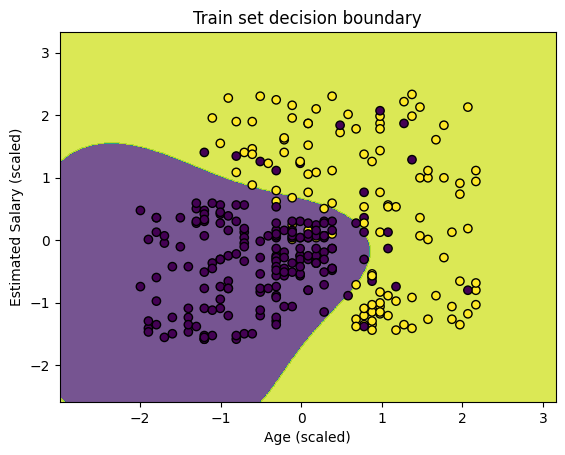

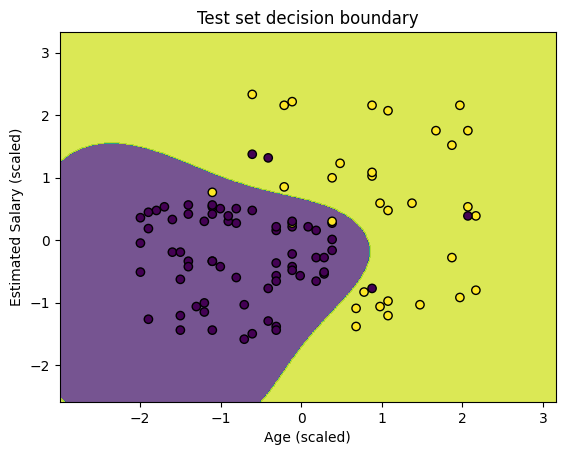

: 

In [ ]:
from matplotlib.colors import ListedColormap

def plot_set(X_set, y_set, title):
    X1, X2 = X_set[:,0], X_set[:,1]
    X1_grid, X2_grid = np.meshgrid(
        np.arange(X1.min()-1, X1.max()+1, 0.01),
        np.arange(X2.min()-1, X2.max()+1, 0.01)
    )
    Z = clf.predict(np.array([X1_grid.ravel(), X2_grid.ravel()]).T).reshape(X1_grid.shape)
    plt.figure()
    plt.contourf(X1_grid, X2_grid, Z, alpha=0.75)
    plt.scatter(X_set[:,0], X_set[:,1], c=y_set, edgecolors='k')
    plt.title(title)
    plt.xlabel('Age (scaled)')
    plt.ylabel('Estimated Salary (scaled)')
    plt.show()

plot_set(X_train_scaled, y_train, "Train set decision boundary")
plot_set(X_test_scaled, y_test, "Test set decision boundary")

---

### Notes
- If you use a differently named CSV (e.g., `Social_Network_Ads.csv`), update the `pd.read_csv(...)` path accordingly.
- The SVM uses default `C` and `gamma`. You can tune these hyperparameters for different decision boundaries and performance.
